In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── run this ONCE at the top, after loading ──
df_raw = pd.read_excel("student_performance_batchwise_2018_2025.xlsx")

df = df_raw.copy()   # fresh copy every run

print(df.shape)           # should be (1792, 13)


(1792, 13)


In [2]:
print(df.dtypes)

Student_ID           object
Student_Name         object
Batch                 int64
Semester              int64
Year                  int64
Mid1                float64
Mid2                float64
Internals           float64
EndTerm             float64
Attendance          float64
Total_Marks         float64
SGPA                float64
Performance_Type     object
dtype: object


In [3]:
print(df.isnull().sum())  # confirm no nulls

Student_ID          0
Student_Name        0
Batch               0
Semester            0
Year                0
Mid1                0
Mid2                0
Internals           0
EndTerm             0
Attendance          0
Total_Marks         0
SGPA                0
Performance_Type    0
dtype: int64


In [4]:
# How many unique students?
print(df['Student_ID'].nunique())  # expect ~224

224


In [5]:
# Does every student have exactly 8 semesters?
sem_counts = df.groupby('Student_ID')['Semester'].count()
print(sem_counts.value_counts())  # should be all 8s

Semester
8    224
Name: count, dtype: int64


In [6]:
# Performance type distribution
print(df['Performance_Type'].value_counts(normalize=True).round(3))

Performance_Type
Average              0.545
Low_Performer        0.179
Consistent_Topper    0.152
Late_Bloomer         0.125
Name: proportion, dtype: float64


### Hypothesis

#### Student performance shows a noticeable dip in the middle semesters (especially Sem 4–5), and this dip can be identified by comparing each semester’s SGPA with the student’s usual performance level. We expect that a personalized, past-based (rolling) approach will detect these dips more realistically than a full-history method.

### Dip Phase — Finding the reality of students when THEY gets a DIP in Results


#### Step 1 — Finding Whole Population's SPGA mean SEM wise

Semester
1    6.809107
2    6.857946
3    6.954777
4    6.764955
5    6.698482
6    7.103705
7    7.231562
8    7.302009
Name: SGPA, dtype: float64


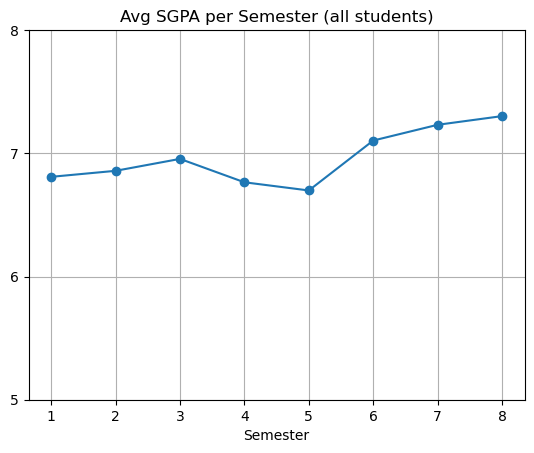

In [7]:
# Just look at the average SGPA per semester across everyone
sem_avg = df.groupby('Semester')['SGPA'].mean()
print(sem_avg)

# Plot it — your eyes will tell you if there's a dip
sem_avg.plot(marker='o', title='Avg SGPA per Semester (all students)')
plt.xticks(range(1, 9))
plt.yticks(range(5, 9))
plt.grid(True)
plt.show()

### Each student's own average SGPA across all 8 sems

In [8]:
df_full = df.copy()

# Personal stats
df_full['Personal_Avg'] = df_full.groupby('Student_ID')['SGPA'].transform('mean')
df_full['Student_STD'] = df_full.groupby('Student_ID')['SGPA'].transform('std')


df_full['Is_Dip_Full'] = df_full['SGPA'] < (df_full['Personal_Avg'] - df_full['Student_STD'])


#df_full.head(25)

### WE can see
#### This approach helps us clearly identify when a student’s performance drops compared to their overall average. However, it uses all 8 semesters, including future data, which is not realistic in real-world scenarios and leads to data leakage. To make the analysis more practical, we need a method that uses only past performance, which is why we move to a rolling approach.


In [9]:
df_roll = df.copy()
df_roll = df_roll.sort_values(['Student_ID', 'Semester'])


df_roll['Rolling_Avg'] = df_roll.groupby('Student_ID')['SGPA'].transform(lambda x: x.expanding().mean())
df_roll['Rolling_STD'] = df_roll.groupby('Student_ID')['SGPA'].transform(lambda x: x.expanding().std())


#### HANDLING NULL values for in STD
##### as STD need 2 values but in case of sem1's we willl only have 1 value so for this error may come-> Value1-NaN

In [10]:
df_roll['Rolling_STD'] = df_roll['Rolling_STD'].fillna(0)

In [11]:
#Finding DIP
df_roll['Is_Dip_Roll'] = df_roll['SGPA'] < (df_roll['Rolling_Avg'] - df_roll['Rolling_STD'])

In [12]:
df_roll

,Student_ID,Student_Name,Batch,Semester,Year,Mid1,Mid2,Internals,EndTerm,Attendance,Total_Marks,SGPA,Performance_Type,Rolling_Avg,Rolling_STD,Is_Dip_Roll
0,S0001,Neha Pal,2018,1,2018,5.39,7.29,8.88,58.08,73.8,50.60,4.93,Low_Performer,4.930000,0.000000,False
1,S0001,Neha Pal,2018,2,2018,7.01,7.03,13.11,55.69,68.9,55.00,5.38,Low_Performer,5.155000,0.318198,False
2,S0001,Neha Pal,2018,3,2019,7.35,6.11,8.07,60.64,68.3,51.86,4.94,Low_Performer,5.083333,0.256970,False
3,S0001,Neha Pal,2018,4,2019,5.82,5.71,8.71,52.67,72.9,46.57,4.92,Low_Performer,5.042500,0.225148,False
4,S0001,Neha Pal,2018,5,2020,6.63,4.54,8.52,60.58,71.2,49.98,4.86,Low_Performer,5.006000,0.211376,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1787,S0224,Sreya Dutta,2025,4,2026,10.69,8.53,11.85,78.98,84.9,70.56,7.62,Average,8.080000,0.411258,True
1788,S0224,Sreya Dutta,2025,5,2027,6.54,6.84,12.13,64.09,75.9,57.56,5.94,Average,7.652000,1.021161,True
1789,S0224,Sreya Dutta,2025,6,2027,9.00,9.03,11.02,85.39,79.5,71.75,7.49,Average,7.625000,0.915746,False
1790,S0224,Sreya Dutta,2025,7,2028,8.36,8.42,14.14,84.51,84.3,73.18,7.40,Average,7.592857,0.840272,False


### FINDING
#### Lets COMPARE both Process we use TO Find The DIP

In [13]:
df_compare = df_full.merge(
    df_roll[['Student_ID', 'Semester', 'Is_Dip_Roll']],
    on=['Student_ID', 'Semester']
)

In [14]:
df_compare.head()

,Student_ID,Student_Name,Batch,Semester,Year,Mid1,Mid2,Internals,EndTerm,Attendance,Total_Marks,SGPA,Performance_Type,Personal_Avg,Student_STD,Is_Dip_Full,Is_Dip_Roll
0,S0001,Neha Pal,2018,1,2018,5.39,7.29,8.88,58.08,73.8,50.60,4.93,Low_Performer,5.15625,0.533477,False,False
1,S0001,Neha Pal,2018,2,2018,7.01,7.03,13.11,55.69,68.9,55.00,5.38,Low_Performer,5.15625,0.533477,False,False
2,S0001,Neha Pal,2018,3,2019,7.35,6.11,8.07,60.64,68.3,51.86,4.94,Low_Performer,5.15625,0.533477,False,False
3,S0001,Neha Pal,2018,4,2019,5.82,5.71,8.71,52.67,72.9,46.57,4.92,Low_Performer,5.15625,0.533477,False,False
4,S0001,Neha Pal,2018,5,2020,6.63,4.54,8.52,60.58,71.2,49.98,4.86,Low_Performer,5.15625,0.533477,False,False


In [15]:
#df.head(15)
df_compare_clean = df_compare[
    [
        'Student_ID',
        'Student_Name',
        'Semester',
        "Total_Marks",
        'SGPA',
        
        'Is_Dip_Full',
        'Is_Dip_Roll',
    ]
]

df_compare_clean.head(25)


,Student_ID,Student_Name,Semester,Total_Marks,SGPA,Is_Dip_Full,Is_Dip_Roll
0,S0001,Neha Pal,1,50.60,4.93,False,False
1,S0001,Neha Pal,2,55.00,5.38,False,False
2,S0001,Neha Pal,3,51.86,4.94,False,False
3,S0001,Neha Pal,4,46.57,4.92,False,False
4,S0001,Neha Pal,5,49.98,4.86,False,False
5,S0001,Neha Pal,6,56.95,5.59,False,False
6,S0001,Neha Pal,7,59.08,6.17,False,False
7,S0001,Neha Pal,8,42.53,4.46,True,True
8,S0002,Ishita Pal,1,70.06,6.65,False,False
9,S0002,Ishita Pal,2,68.02,6.77,False,False


In [16]:
print("Full method dips:", df_compare_clean['Is_Dip_Full'].sum())
print("Rolling method dips:", df_compare_clean['Is_Dip_Roll'].sum())

Full method dips: 289
Rolling method dips: 197


In [17]:
dip_full = df_compare_clean.groupby('Semester')['Is_Dip_Full'].mean() * 100
dip_roll = df_compare_clean.groupby('Semester')['Is_Dip_Roll'].mean() * 100

print(dip_full.round(1))
print()
print(dip_roll.round(1))

Semester
1    23.7
2    18.3
3    10.7
4    19.6
5    31.7
6    11.2
7     8.0
8     5.8
Name: Is_Dip_Full, dtype: float64

Semester
1     0.0
2     0.0
3    12.1
4    24.1
5    27.7
6    10.3
7     8.0
8     5.8
Name: Is_Dip_Roll, dtype: float64


## CONCLUSION



#### We observe a clear difference between the two methods. The full-history method(1ST) detects significantly more dips, while the rolling method(2ND) shows fewer dips. This is expected because the rolling approach uses only past data, making it stricter and more realistic.

#### However, despite this difference in scale, both methods show a consistent pattern.

#### In both cases, the highest number of dips occur around Semester 3, 4, and 5. This strongly supports our hypothesis that students tend to experience a performance dip during the middle phase of their academic journey.

#### The rolling method further strengthens this observation, as it clearly highlights this pattern without relying on future data.



### Even though the number of dips differs, the underlying trend remains the same — mid semesters (3–5) are the most critical period where students are more likely to struggle academically.


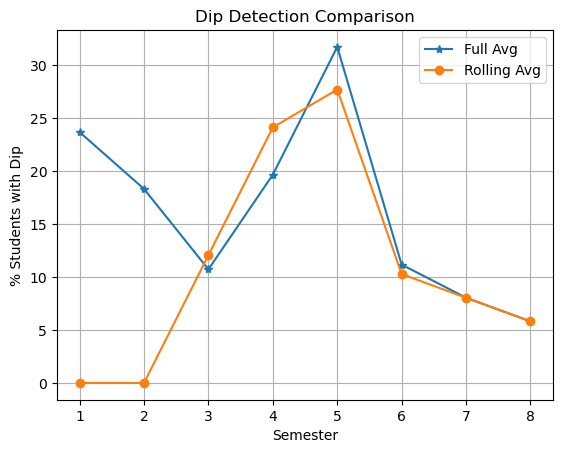

In [18]:
plt.plot(dip_full.index, dip_full, marker='*', label='Full Avg')
plt.plot(dip_roll.index, dip_roll, marker='o', label='Rolling Avg')

plt.title("Dip Detection Comparison")
plt.xlabel("Semester")
plt.ylabel("% Students with Dip")
plt.legend()
plt.grid(True)
plt.show()

# PART 2

# Impact of Question Bank (QB) on Student Performance

#### We analyze student performance before and after the introduction of the Question Bank (QB) in 2022 to understand its impact on SGPA, score consistency, and the distribution of top and low performers.


### WE will find hw SEMESTER WISE Peformance Changed

In [19]:
df.head()

,Student_ID,Student_Name,Batch,Semester,Year,Mid1,Mid2,Internals,EndTerm,Attendance,Total_Marks,SGPA,Performance_Type
0,S0001,Neha Pal,2018,1,2018,5.39,7.29,8.88,58.08,73.8,50.60,4.93,Low_Performer
1,S0001,Neha Pal,2018,2,2018,7.01,7.03,13.11,55.69,68.9,55.00,5.38,Low_Performer
2,S0001,Neha Pal,2018,3,2019,7.35,6.11,8.07,60.64,68.3,51.86,4.94,Low_Performer
3,S0001,Neha Pal,2018,4,2019,5.82,5.71,8.71,52.67,72.9,46.57,4.92,Low_Performer
4,S0001,Neha Pal,2018,5,2020,6.63,4.54,8.52,60.58,71.2,49.98,4.86,Low_Performer


## BATCH BASED Comparison

In [20]:
# QB Era flag — your most important hypothesis variable
df['QB_Era'] = df['Batch'].apply(lambda x: 'Post_QB' if x >= 2022 else 'Pre_QB')

In [21]:
# AVG CGPA
df.groupby('QB_Era')["SGPA"].mean()

QB_Era
Post_QB    7.257102
Pre_QB     6.683772
Name: SGPA, dtype: float64

In [22]:
# STD CGPA
df.groupby('QB_Era')["SGPA"].std()

QB_Era
Post_QB    1.168804
Pre_QB     1.219739
Name: SGPA, dtype: float64

#### TOPPERS percentage

he in Data We had a Column which already States PERFORMANCE_TYPE of Student

In [23]:
df[df['Performance_Type'] == 'Consistent_Topper'].groupby('QB_Era').size() / df.groupby('QB_Era').size() * 100

QB_Era
Post_QB    22.727273
Pre_QB      7.894737
dtype: float64

### Conlusion Based ON BATCH based Analysis

## YEAR BASED comparison 

In [24]:
df["QB_Era_Year"] = df['Year'].apply(lambda x: 'Post_QB' if x >= 2022 else 'Pre_QB' )

# AVG CGPA
df.groupby('QB_Era_Year')["SGPA"].mean()

# STD CGPA
df.groupby("QB_Era_Year")["SGPA"].mean()

QB_Era_Year
Post_QB    7.189303
Pre_QB     6.469982
Name: SGPA, dtype: float64

#### Topper Percentages

In [25]:
df[df["Performance_Type"] == 'Consistent_Topper'].groupby('QB_Era_Year').size()/ df.groupby("QB_Era_Year").size() * 100

QB_Era_Year
Post_QB    18.152350
Pre_QB      8.602151
dtype: float64

### ConClusioon Of YEAR BASED Method


#### This is useful because it allows us to compare the same student before and after QB, removing individual differences.

## WITHIN-STUDENT Analysis

In [26]:
#df['QB_Era_Year'] = df['Year'].apply(lambda x: 1 if x >= 2022 else 0)

In [27]:
student_era_avg = df.groupby(['Student_ID', 'QB_Era_Year'])['SGPA'].mean().unstack()

student_era_avg

QB_Era_Year,Post_QB,Pre_QB
Student_ID,,
S0001,NaN,5.15625
S0002,NaN,6.50875
S0003,NaN,7.08625
S0004,NaN,6.34625
S0005,NaN,7.01375
...,...,...
S0220,8.5950,NaN
S0221,7.4575,NaN
S0222,6.7725,NaN


#### KEEPING the Students those who Has Been in BOTH ERA (BEfore and After QB)

In [31]:
student_era_avg = student_era_avg.dropna()
student_era_avg

QB_Era_Year,Post_QB,Pre_QB,Improvement
Student_ID,,,
S0026,6.755000,6.261667,0.493333
S0027,7.265000,7.180000,0.085000
S0028,7.560000,7.236667,0.323333
S0029,6.510000,6.341667,0.168333
S0030,5.670000,4.928333,0.741667
...,...,...,...
S0110,7.326667,5.695000,1.631667
S0111,7.193333,7.190000,0.003333
S0112,7.733333,6.990000,0.743333


In [32]:
# CALCULATING IMPROVEMENT

student_era_avg['Improvement'] = (student_era_avg['Post_QB'] - student_era_avg['Pre_QB'])
student_era_avg

QB_Era_Year,Post_QB,Pre_QB,Improvement
Student_ID,,,
S0026,6.755000,6.261667,0.493333
S0027,7.265000,7.180000,0.085000
S0028,7.560000,7.236667,0.323333
S0029,6.510000,6.341667,0.168333
S0030,5.670000,4.928333,0.741667
...,...,...,...
S0110,7.326667,5.695000,1.631667
S0111,7.193333,7.190000,0.003333
S0112,7.733333,6.990000,0.743333


#### IMPROVEMENT Calculation

In [42]:
impv = student_era_avg['Improvement'].mean()
print(f"CPGA improved {impv} points")

CPGA improved 0.5534644194756553 points


In [44]:
# PERCENtaGE of Improvement Students
impv_Student = (student_era_avg['Improvement'] > 0).mean() * 100
print(impv_Student)

78.65168539325843


### Conclusion — Within-Student Analysis

In [ ]:
#### 

### IF we Dont have the PERFORMANCE_TYPE in Students dataset,
#### we had 2 ways of Doing that,,-->    1) Simple Binning based on the CPGA or Percentile Based (this will split in Equal parts) 
#### ---------------------------------->    2) K-Mean Custering
